# Native Jaxley L5PC simulation

Run a native Jaxley Layer 5 pyramidal cell model, adjust a current-clamp stimulus, visualise the voltage response, and extract electrophysiological features with eFEL.


## 1. Imports and model setup

This cell imports the required packages and loads the L5PC model.


In [1]:
import sys
from pathlib import Path

from jax import config

config.update("jax_enable_x64", True)

import efel
import ipywidgets as widgets
import jax.numpy as jnp
import jaxley as jx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Add the local jaxley-models repository if it is bundled next to this notebook.
JAXLEY_MODELS_REPO = Path.cwd() / "jaxley-models"
if JAXLEY_MODELS_REPO.exists():
    sys.path.insert(0, str(JAXLEY_MODELS_REPO.resolve()))

from jaxley_models.l5pc import L5PC

print("Jaxley L5PC model imported successfully.")


Jaxley L5PC model imported successfully.


## 2. Choose the stimulus

Use the controls below to set the current-clamp stimulus and the stimulation/recording locations. The default values should produce a visible voltage response.


In [2]:
model_config = {
    "model_name": "L5PC",
    "ncomp": 4,
    "max_branch_len_um": 300.0,
}

dt_widget = widgets.FloatText(value=0.025, description="dt [ms]")
t_max_widget = widgets.FloatSlider(value=100.0, min=50.0, max=500.0, step=10.0, description="t_max [ms]")

stim_delay_widget = widgets.FloatSlider(value=20.0, min=0.0, max=200.0, step=5.0, description="Delay [ms]")
stim_duration_widget = widgets.FloatSlider(value=60.0, min=5.0, max=300.0, step=5.0, description="Duration [ms]")
stim_amplitude_widget = widgets.FloatSlider(value=0.6, min=-1.0, max=2.0, step=0.05, description="I [nA]")

stim_branch_widget = widgets.IntText(value=0, description="Stim branch")
stim_location_widget = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.05, description="Stim loc")

record_branch_widget = widgets.IntText(value=0, description="Rec branch")
record_location_widget = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.05, description="Rec loc")


def get_protocol_config() -> dict:
    """Collect the current widget values into a protocol configuration dictionary."""
    return {
        "dt_ms": float(dt_widget.value),
        "t_max_ms": float(t_max_widget.value),
        "stim_delay_ms": float(stim_delay_widget.value),
        "stim_duration_ms": float(stim_duration_widget.value),
        "stim_amplitude_nA": float(stim_amplitude_widget.value),
        "stim_branch_index": int(stim_branch_widget.value),
        "stim_location": float(stim_location_widget.value),
        "record_branch_index": int(record_branch_widget.value),
        "record_location": float(record_location_widget.value),
    }


display(
    widgets.VBox(
        [
            widgets.HTML("<b>Current-clamp stimulus</b>"),
            dt_widget,
            t_max_widget,
            stim_delay_widget,
            stim_duration_widget,
            stim_amplitude_widget,
            widgets.HTML("<b>Stimulation site</b>"),
            stim_branch_widget,
            stim_location_widget,
            widgets.HTML("<b>Recording site</b>"),
            record_branch_widget,
            record_location_widget,
        ]
    )
)

print("Current protocol config:")
display(pd.DataFrame([get_protocol_config()]))


Current protocol config:


,dt_ms,t_max_ms,stim_delay_ms,stim_duration_ms,stim_amplitude_nA,stim_branch_index,stim_location,record_branch_index,record_location
0,0.025,100.0,20.0,60.0,0.6,0,0.0,0,0.0


## 3. Simulation and feature-extraction helpers

The functions below build the model, run the simulation, plot the voltage trace, and extract eFEL features.


In [3]:
DEFAULT_EFEL_FEATURES = [
    "voltage_base",
    "voltage_deflection",
    "maximum_voltage",
    "minimum_voltage",
    "AP_amplitude",
    "AP_width",
    "Spikecount",
    "time_to_first_spike",
    "mean_frequency",
]


def build_l5pc_model(config: dict):
    """Build the native Jaxley L5PC model from jaxley-models."""
    return L5PC(
        ncomp=config["ncomp"],
        max_branch_len=config["max_branch_len_um"],
    )


def step_current_from_protocol(protocol: dict):
    """Create a Jaxley step current, supporting both recent and older argument names."""
    kwargs = {
        "i_delay": protocol["stim_delay_ms"],
        "i_dur": protocol["stim_duration_ms"],
        "i_amp": protocol["stim_amplitude_nA"],
        "t_max": protocol["t_max_ms"],
    }

    try:
        return jx.step_current(delta_t=protocol["dt_ms"], **kwargs)
    except TypeError:
        return jx.step_current(dt=protocol["dt_ms"], **kwargs)


def run_jaxley_l5pc(model_config: dict, protocol_config: dict):
    """Run the native Jaxley L5PC model and return time, voltage, and cell."""
    cell = build_l5pc_model(model_config)
    current = step_current_from_protocol(protocol_config)

    stim_site = cell.branch(protocol_config["stim_branch_index"]).loc(
        protocol_config["stim_location"]
    )
    record_site = cell.branch(protocol_config["record_branch_index"]).loc(
        protocol_config["record_location"]
    )

    stim_site.stimulate(current)
    record_site.record("v")

    voltage = jx.integrate(cell, delta_t=protocol_config["dt_ms"])
    time = jnp.arange(voltage.shape[-1]) * protocol_config["dt_ms"]

    return np.asarray(time), np.asarray(voltage[0]), cell


def plot_voltage_trace(time_ms, voltage_mV, protocol):
    """Plot the simulated voltage trace inside the notebook."""
    plt.figure(figsize=(9, 4))
    plt.plot(time_ms, voltage_mV, label="voltage")
    plt.axvspan(
        protocol["stim_delay_ms"],
        protocol["stim_delay_ms"] + protocol["stim_duration_ms"],
        alpha=0.15,
        label="stimulus",
    )
    plt.xlabel("Time [ms]")
    plt.ylabel("Voltage [mV]")
    plt.title("Jaxley L5PC voltage response")
    plt.legend()
    plt.tight_layout()
    plt.show()


def _summarise_efel_value(value):
    """Return a display-friendly summary and raw values for an eFEL value."""
    if value is None:
        return None, None

    arr = np.asarray(value)
    if arr.size == 0:
        return None, []
    if arr.ndim == 0 or arr.size == 1:
        scalar = float(arr.reshape(-1)[0])
        return scalar, [scalar]

    values = arr.astype(float).tolist()
    return float(np.mean(arr)), values


def extract_efel_features(time_ms, voltage_mV, protocol, feature_names=None):
    """Extract eFEL features from a voltage trace."""
    if feature_names is None:
        feature_names = DEFAULT_EFEL_FEATURES

    trace = {
        "T": np.asarray(time_ms),
        "V": np.asarray(voltage_mV),
        "stim_start": [protocol["stim_delay_ms"]],
        "stim_end": [protocol["stim_delay_ms"] + protocol["stim_duration_ms"]],
    }

    feature_values = efel.get_feature_values([trace], feature_names)[0]

    rows = []
    for name, value in feature_values.items():
        summary, raw_values = _summarise_efel_value(value)
        rows.append(
            {
                "feature": name,
                "value": summary,
                "raw_values": raw_values,
            }
        )

    return pd.DataFrame(rows)


## 4. Run the simulation

Run this cell after adjusting the stimulus controls above.


/Users/ilkankilic/Workspace/obi_platform_analysis_notebooks/.venv/lib/python3.11/site-packages/jaxley/utils/misc_utils.py:63: UserWarning: distance is deprecated and will be removed in version 0.11.0. Instead, please use, e.g., `jx.morphology_utils.distance(cell[0, 0], cell[2, 1], kind='direct')`. Note that, unlike `cell[0, 0].distance(cell[2, 1]), that function returns a list of distances (to all endpoints).
  warnings.warn(msg + self._amend_msg)
/Users/ilkankilic/Workspace/obi_platform_analysis_notebooks/.venv/lib/python3.11/site-packages/jaxley/utils/misc_utils.py:63: UserWarning: distance is deprecated and will be removed in version 0.11.0. Instead, please use, e.g., `jx.morphology_utils.distance(cell[0, 0], cell[2, 1], kind='direct')`. Note that, unlike `cell[0, 0].distance(cell[2, 1]), that function returns a list of distances (to all endpoints).
  warnings.warn(msg + self._amend_msg)
/Users/ilkankilic/Workspace/obi_platform_analysis_notebooks/.venv/lib/python3.11/site-packages/j

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Simulation finished.
Voltage range [mV]: -82.14430336074723 to 31.400300158586667


,dt_ms,t_max_ms,stim_delay_ms,stim_duration_ms,stim_amplitude_nA,stim_branch_index,stim_location,record_branch_index,record_location
0,0.025,100.0,20.0,60.0,0.6,0,0.0,0,0.0


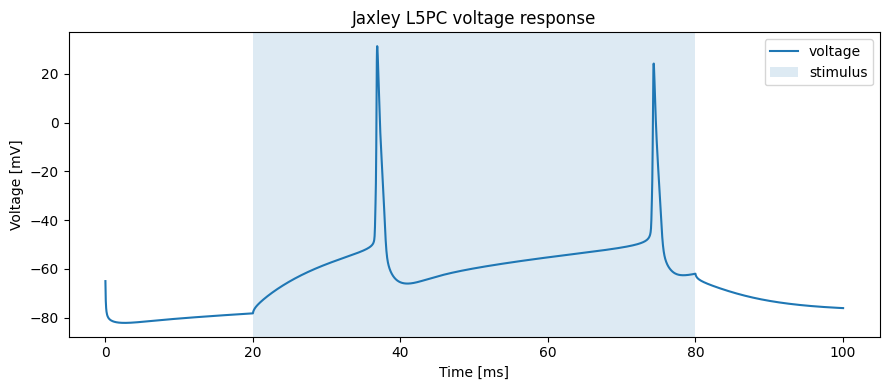

In [4]:
protocol_config = get_protocol_config()

time_ms, voltage_mV, cell = run_jaxley_l5pc(model_config, protocol_config)

print("Simulation finished.")
print("Voltage range [mV]:", float(np.min(voltage_mV)), "to", float(np.max(voltage_mV)))

display(pd.DataFrame([protocol_config]))
plot_voltage_trace(time_ms, voltage_mV, protocol_config)


## 5. Extract eFEL features

The table below summarises electrophysiological features extracted from the simulated voltage trace.


In [5]:
ef_features = extract_efel_features(time_ms, voltage_mV, protocol_config)
display(ef_features)


,feature,value,raw_values
0,voltage_base,-78.411494,[-78.41149351316858]
1,voltage_deflection,17.853953,[17.85395293533496]
2,maximum_voltage,29.450610,[29.45061029561279]
3,minimum_voltage,-78.228730,[-78.22873012731145]
4,AP_amplitude,72.704595,"[78.23182306230663, 67.17736705261022]"
5,AP_width,0.850000,"[0.9000000000000128, 0.7999999999999545]"
6,Spikecount,2.000000,[2.0]
7,time_to_first_spike,16.900000,[16.900000000000254]
8,mean_frequency,36.832413,[36.832412523020224]


## 6. Try another stimulus

Change the current amplitude, stimulus duration, or recording location above, then rerun the simulation and feature-extraction cells.
